In [3]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model

image_folder = "flood_dataset"
IMG_SIZE = 256

COLORS = np.array([
    [0, 255, 0],      # Class 0
    [100, 255, 100],  # Class 1
    [0, 255, 255],    # Class 2
    [0, 0, 255],      # Class 3
    [0, 0, 139]       # Class 4
])

def create_mask(img):
    """Converts an RGB mask image into a single-channel label map (0-4)."""
    img_flat = img.reshape(-1, 3)
    distances = np.linalg.norm(img_flat[:, None] - COLORS, axis=2)
    mask = np.argmin(distances, axis=1)
    return mask.reshape(img.shape[0], img.shape[1])

files = [f for f in os.listdir(image_folder) if f.endswith((".png", ".jpg", ".jpeg"))][:61]
images, masks = [], []

for filename in files:
    path = os.path.join(image_folder, filename)
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    images.append(img)
    masks.append(create_mask(img))

# Normalize images to [0, 1] and convert to numpy arrays
X_train = np.array(images) / 255.0
y_train = np.array(masks)

print(f"Loaded {len(X_train)} images.")
print(f"Image shape: {X_train.shape}")
print(f"Mask shape: {y_train.shape}")  

Loaded 61 images.
Image shape: (61, 256, 256, 3)
Mask shape: (61, 256, 256)


In [2]:
# Add this function to Cell 1
def get_segmentation_boundaries(mask_array):
    """
    Takes a single-channel segmentation mask (labels 0-4) 
    and returns an outline image of the class boundaries.
    """
    mask_scaled = (mask_array * (255 // 4)).astype(np.uint8)
    
    # Canny edge detection
    edges = cv2.Canny(mask_scaled, threshold1=10, threshold2=100)
    return edges

In [3]:
def build_simple_cnn():
    model = tf.keras.Sequential([
        # Input layer
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        
        # Convolutional Layers 
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        
        # last Layer: 5 filters (one for each class) 
        layers.Conv2D(5, (1, 1), activation='softmax')
    ])
    return model

cnn_model = build_simple_cnn()
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 5)    │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,893 (366.77 KB)

 Trainable params: 93,893 (366.77 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
print("Starting training...")
history = cnn_model.fit(
    X_train, 
    y_train, 
    epochs=100,   
    batch_size=3,   
    verbose=1
)
print("Training complete.")

Starting training...
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 321ms/step - accuracy: 0.6364 - loss: 1.2752
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - accuracy: 0.9469 - loss: 0.3954
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - accuracy: 0.9469 - loss: 0.2156
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 335ms/step - accuracy: 0.9469 - loss: 0.2596
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 329ms/step - accuracy: 0.9469 - loss: 0.2409
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 322ms/step - accuracy: 0.9470 - loss: 0.1837
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.9516 - loss: 0.1729
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 321ms/step - accuracy: 0.9487 - loss: 0.1395
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - accuracy: 0.9559 - loss: 0.1262
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step - accuracy: 0.9670 - loss: 0.1149
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step - accuracy: 0.9687 - loss: 0.1085
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 3

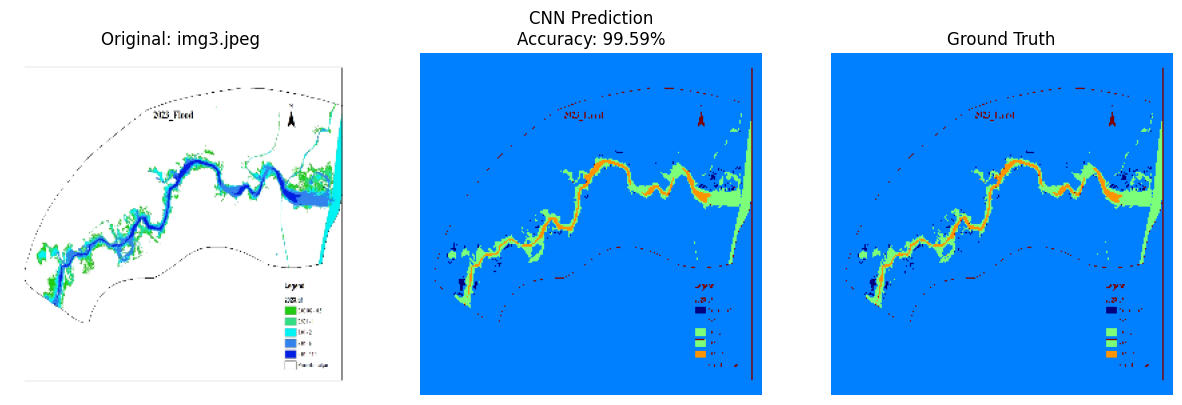

In [12]:
# random index from 9 images
idx = np.random.randint(0, len(X_train))
sample_img = X_train[idx]
sample_gt = y_train[idx]

# Predict 
prediction = cnn_model.predict(np.expand_dims(sample_img, 0), verbose=0)

pred_mask = np.argmax(prediction, axis=-1)[0]

#pixel accuracy
acc = np.sum(pred_mask == sample_gt) / sample_gt.size

#plotting
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_img)
plt.title(f"Original: {files[idx]}")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(pred_mask, cmap='jet')
plt.title(f"CNN Prediction\nAccuracy: {acc:.2%}")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sample_gt, cmap='jet')
plt.title("Ground Truth")
plt.axis('off')

plt.show()

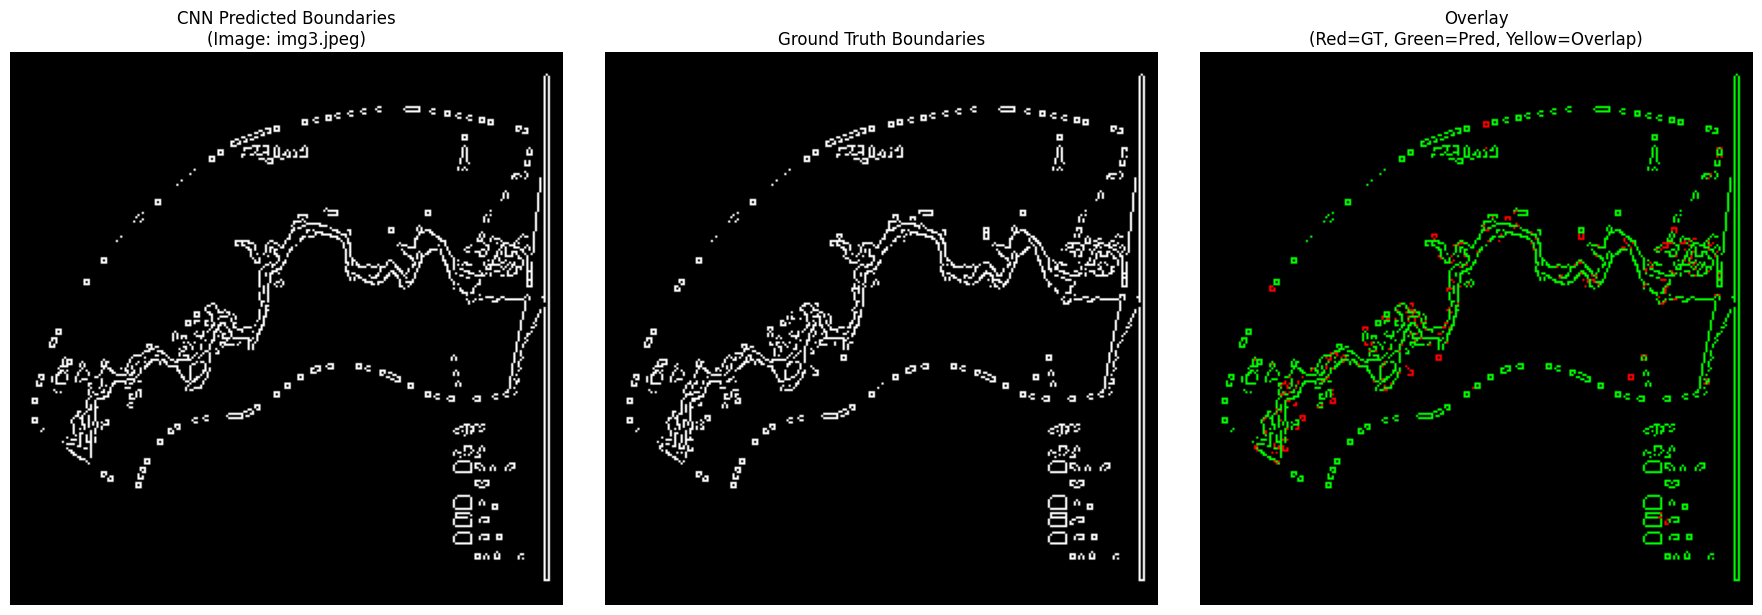

In [13]:

plt.figure(figsize=(18, 6))

# Predicted Boundaries
plt.subplot(1, 3, 1)
cnn_boundaries = get_segmentation_boundaries(pred_mask)
plt.imshow(cnn_boundaries, cmap='gray')
plt.title(f"CNN Predicted Boundaries\n(Image: {files[idx]})")
plt.axis('off')

#Ground Truth Boundaries
plt.subplot(1, 3, 2)
gt_boundaries = get_segmentation_boundaries(sample_gt)
plt.imshow(gt_boundaries, cmap='gray')
plt.title("Ground Truth Boundaries")
plt.axis('off')

# 3. Intersection (Overlaying Pred and GT in color)
plt.subplot(1, 3, 3)

# Create a black background image
intersection_rgb = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

# Red = Where Ground Truth says edges are
intersection_rgb[gt_boundaries > 0] = [255, 0, 0] 

# Green = Where CNN says edges are
intersection_rgb[cnn_boundaries > 0] = [0, 255, 0] 

# Yellow/Cyan (Mix) = Where they overlap

plt.imshow(intersection_rgb)
plt.title("Overlay\n(Red=GT, Green=Pred, Yellow=Overlap)")
plt.axis('off')

plt.tight_layout()
plt.show()